In [7]:
# Customer Segmentation with PCA

In [8]:
# gender, age, annual income, spending score

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



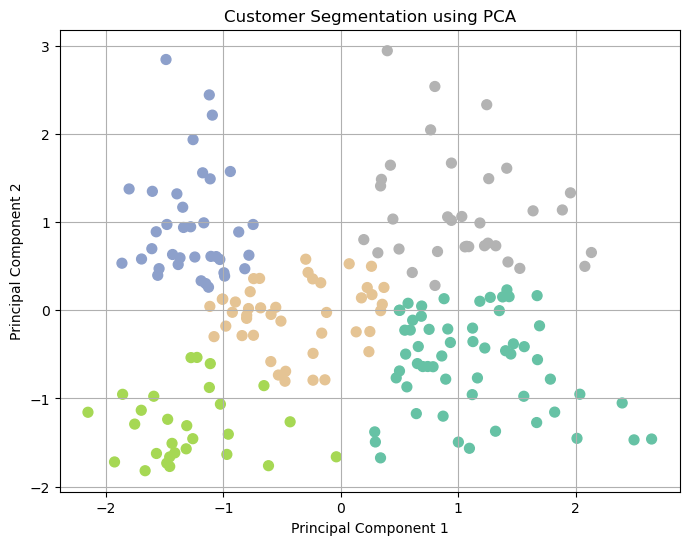

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
url = 'D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\Unsupervised Learning Clustering-18\\Mall_Customers.csv'
df = pd.read_csv(url)

# Select numerical features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans clustering (optional)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set2', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segmentation using PCA')
plt.grid(True)
plt.show()


C:\Users\Lenovo\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



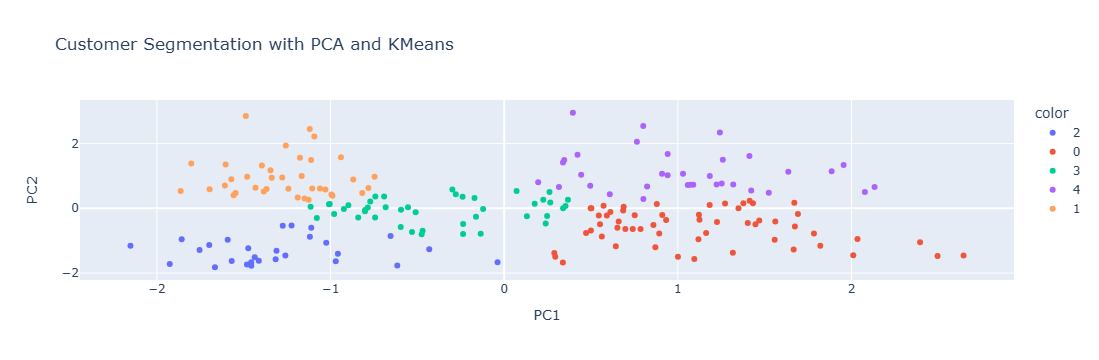

In [10]:
import plotly.express as px
# Create interactive scatter plot
fig = px.scatter(
    x=X_pca[:, 0], y=X_pca[:, 1],
    color=labels.astype(str),
    labels={'x': 'PC1', 'y': 'PC2'},
    title='Customer Segmentation with PCA and KMeans',
    hover_data={'CustomerID': df['CustomerID'], 'Gender': df['Gender'], 'Age': df['Age']}
)
fig.show()


In [11]:
# classification model
#Logistic Regression classifier using PCA-transformed data to predict cluster labels

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, labels, test_size=0.2, random_state=42)

# Train classifier
clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.875
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           1       1.00      1.00      1.00         5
           2       1.00      0.80      0.89         5
           3       0.90      0.75      0.82        12
           4       1.00      0.90      0.95        10

    accuracy                           0.88        40
   macro avg       0.91      0.89      0.89        40
weighted avg       0.90      0.88      0.88        40

